In [1]:
import numpy as np, curvedsky as cs, plottools as pl, cmb as CMB, cosmology, healpy as hp
import pysm3
import pysm3.units as u
from matplotlib.pyplot import *
import warnings
warnings.filterwarnings("ignore")
ac2rad  = np.pi/10800.
deg2rad = np.pi/180.
Tcmb  = CMB.Tcmb    # CMB temperature

In [2]:
def foreground(nu,L,dust=1.,sync=1.):
    dBB = dust*(4.7/CMB.Tcmb**2)*(L/80)**(-0.58) * (CMB.Int_dust(nu)/CMB.Int_dust(353.))**2/(L*(L+1)/2./np.pi) 
    sBB = sync*(1.5/CMB.Tcmb**2)*(L/80.)**(-0.27)*(nu/2.3)**(-3.1)
    fBB = dBB + sBB
    fEE = 2*fBB
    return fEE, fBB

In [3]:
Lmax  = 3000       # maximum multipole of output normalization
rlmin, rlmax = 50, Lmax  # CMB multipole range for reconstruction
L = np.linspace(0,Lmax,Lmax+1)
Lfac = L*(L+1)/2/np.pi

In [4]:
ucl = CMB.read_camb_cls('data/cosmo2017_10K_acc3_scalCls.dat',output='array')[:,:Lmax+1]
lcl = CMB.read_camb_cls('data/cosmo2017_10K_acc3_lensedCls.dat',ftype='lens',output='array')[:,:Lmax+1]

In [80]:
Q0 = hp.read_map('/project/projectdirs/cmb/data/planck2015/pr2/foregroundmaps/COM_CompMap_DustPol-commander_1024_R2.00.fits',field=2)/CMB.Tcmb
U0 = hp.read_map('/project/projectdirs/cmb/data/planck2015/pr2/foregroundmaps/COM_CompMap_DustPol-commander_1024_R2.00.fits',field=3)/CMB.Tcmb
Q1 = hp.read_map('/project/projectdirs/cmb/data/planck2015/pr2/foregroundmaps/COM_CompMap_DustPol-commander_1024_R2.00.fits',field=4)/CMB.Tcmb
U1 = hp.read_map('/project/projectdirs/cmb/data/planck2015/pr2/foregroundmaps/COM_CompMap_DustPol-commander_1024_R2.00.fits',field=5)/CMB.Tcmb

In [63]:
#Q = hp.read_map('/project/projectdirs/cmb/data/planck2015/pr2/foregroundmaps/COM_CompMap_SynchrotronPol-commander_0256_R2.00.fits',field=1)/CMB.Tcmb
#U = hp.read_map('/project/projectdirs/cmb/data/planck2015/pr2/foregroundmaps/COM_CompMap_SynchrotronPol-commander_0256_R2.00.fits',field=2)/CMB.Tcmb

In [85]:
Q0 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_353_2048_R3.01_halfmission-1.fits',field=1)/CMB.Tcmb
U0 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_353_2048_R3.01_halfmission-1.fits',field=2)/CMB.Tcmb

In [86]:
Q1 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_353_2048_R3.01_halfmission-2.fits',field=1)/CMB.Tcmb
U1 = hp.read_map('/project/projectdirs/cmb/data/planck2018/pr3/frequencymaps/HFI_SkyMap_353_2048_R3.01_halfmission-2.fits',field=2)/CMB.Tcmb

In [92]:
mask = hp.read_map('../plk_biref/data/HFI_Mask_PointSrc_2048_R2.00.fits')

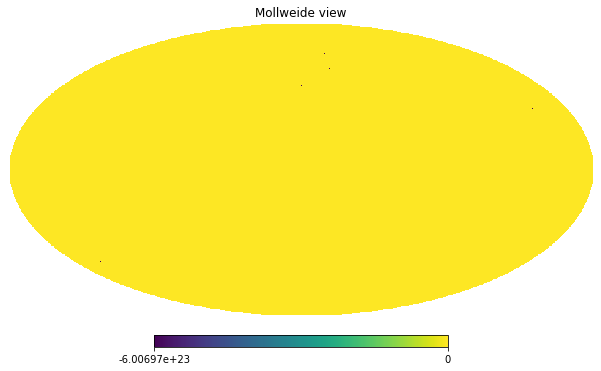

In [96]:
hp.mollview(mask*Q0)

In [88]:
nside = 2048
lmax  = 2048
Elm0, Blm0 = cs.utils.hp_map2alm_spin(nside,lmax,lmax,2,Q0,U0)
Elm1, Blm1 = cs.utils.hp_map2alm_spin(nside,lmax,lmax,2,Q1,U1)

In [89]:
EE = cs.utils.alm2cl(lmax,Elm0,Elm1)
BB = cs.utils.alm2cl(lmax,Blm0,Blm1)

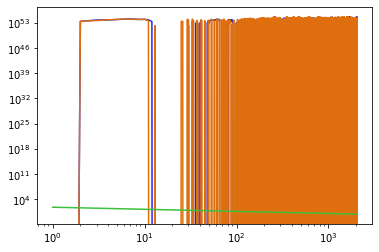

In [90]:
Ls = np.linspace(0,lmax,lmax+1)
fac = Ls*(Ls+1)*CMB.Tcmb**2/2/np.pi
dEE, dBB = foreground(353,Ls,sync=0.)
xscale('log')
yscale('log')
plot(fac*EE)
plot(fac*BB)
#plot(EB)
plot(fac*dBB)

In [52]:
nside = 512
lmax = 2*nside

In [53]:
dsky = pysm3.Sky(nside=nside, preset_strings=["d1"])
ssky = pysm3.Sky(nside=nside, preset_strings=["s1"])

In [54]:
dsky.components
ssky.components

In [55]:
dmap_353GHz = dsky.get_emission(353 * u.GHz)
smap_100GHz = ssky.get_emission(100 * u.GHz)

In [56]:
dmap_353GHz = dmap_353GHz.to(u.uK_CMB, equivalencies=u.cmb_equivalencies(353*u.GHz))
smap_100GHz = smap_100GHz.to(u.uK_CMB, equivalencies=u.cmb_equivalencies(100*u.GHz))

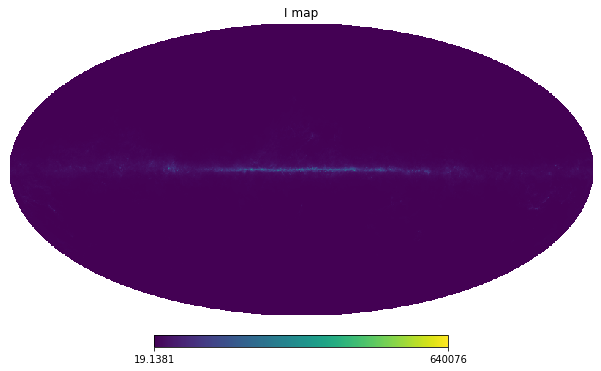

In [57]:
hp.mollview(dmap_353GHz[0], title="I map")

In [58]:
Q = dmap_353GHz[1]/CMB.Tcmb
U = dmap_353GHz[2]/CMB.Tcmb
Elm, Blm = cs.utils.hp_map2alm_spin(nside,lmax,lmax,2,Q,U)

In [59]:
EE = cs.utils.alm2cl(lmax,Elm)
BB = cs.utils.alm2cl(lmax,Blm)
EB = cs.utils.alm2cl(lmax,Elm,Blm)

In [60]:
fEE, fBB = foreground(353,L,sync=0.)

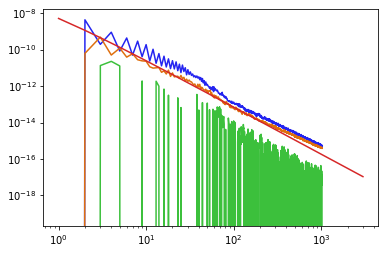

In [61]:
xscale('log')
yscale('log')
plot(EE)
plot(BB)
plot(EB)
plot(fEE*1e2)